<a href="https://colab.research.google.com/github/SofiaFreiman/Lung_epitelium/blob/main/Pseudotime_analysis_(manuscript_plots_2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install --force-reinstall -v "scipy==1.13"
!pip install scanpy leidenalg scikit-misc
import os
os.kill(os.getpid(), 9)

In [1]:
import warnings
warnings.filterwarnings("ignore")

import time
import os
import re
import pandas as pd
import numpy as np
import scipy.stats
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import anndata

sc.settings.verbosity = 1
sns.set(font_scale = 1.5)
sns.set_style("whitegrid")

plt.rcParams['font.family'] = 'Liberation Serif'

In [2]:
l2_colors = {'Basal cells': 'tab:green', 'Suprabasal cells': 'darkseagreen', 'Goblet cells': 'mediumaquamarine', 'Secretory cells': 'burlywood', 'Ciliated cells': 'mediumpurple', 'Ionocytes': 'orangered', 'Deuterosomal cells': 'deeppink'}
l3_colors = {'Basal cells' : "tab:green", 'Suprabasal cells' : "darkseagreen", "Goblet cells" : "mediumaquamarine", "Secretory cells" : "burlywood", "Multi-ciliated cells 1" : "cornflowerblue", "Multi-ciliated cells 2" : "mediumpurple", "Ionocytes" : "orangered", "Deuterosomal cells" : "deeppink"}

path = "drive/MyDrive/LU/Pavan_data/"
path_figs = "drive/MyDrive/LU/Pavan_data/figs/"
path_DE = "drive/MyDrive/LU/Pavan_data/DEGs/"
path_figs_svg = "drive/MyDrive/LU/Pavan_data/figs/svg/"

adata = sc.read(path + "adata_current.h5ad")

In [30]:
!rm -r omic_plots/

In [3]:
!git clone https://github.com/SofiaFreiman/omic_plots.git
from omic_plots.pseudotime_gene_expression import pseudotime_gene_expression
from omic_plots.cells_along_trj import cells_along_trj

Cloning into 'omic_plots'...
remote: Enumerating objects: 18, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 18 (delta 5), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (18/18), 8.09 KiB | 1.16 MiB/s, done.
Resolving deltas: 100% (5/5), done.


## Pseudotime dotplot and marker genes

8.334516


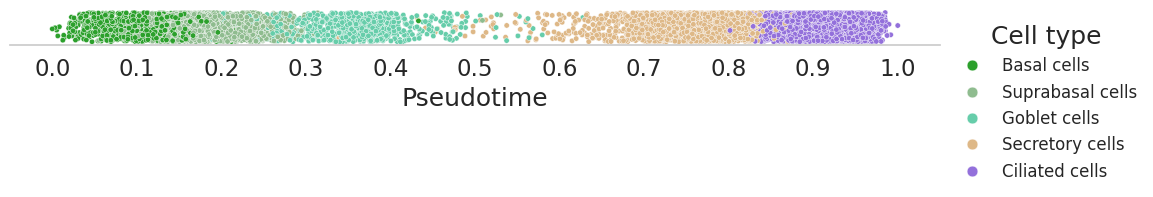

In [5]:
# Using script from my Github

l2_colors_short = {'Basal cells': 'tab:green', 'Suprabasal cells': 'darkseagreen', 'Goblet cells': 'mediumaquamarine', 'Secretory cells': 'burlywood', 'Ciliated cells': 'mediumpurple'}

subset = adata[adata.obs['anno_l2'].isin(['Basal cells', 'Suprabasal cells', 'Goblet cells', 'Secretory cells', 'Ciliated cells'])].copy()
print(subset.X.max())

ax = cells_along_trj(subset, cell_color_dict = l2_colors_short, anno_col = 'anno_l2')

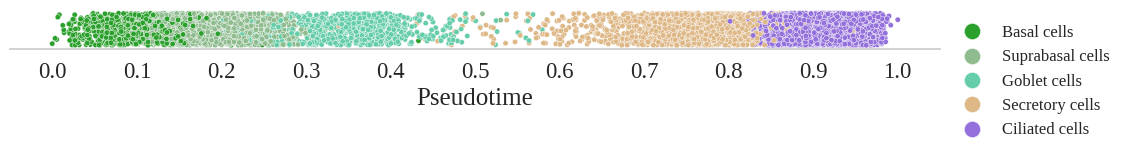

In [9]:
# Same plot but with this particular font

def cell_along_trj(adata, cell_color_dict = l2_colors, anno_col = 'anno'):
  df = pd.DataFrame()
  df['Pseudotime'] = adata.obs['dpt_pseudotime']
  adata.obs[anno_col] = adata.obs[anno_col].cat.remove_unused_categories()
  df["Cell type"] = adata.obs[anno_col]
  sns.set(font_scale = 1.5)
  sns.set_style("whitegrid")
  plt.rcParams['font.family'] = 'Liberation Serif'

  fig, ax = plt.subplots(figsize = (12, 0.5))
  sns.scatterplot(x = df.Pseudotime, y=np.random.random(len(df)), hue = df['Cell type'], s=15, hue_order = cell_color_dict.keys(),
                  palette = cell_color_dict, ax = ax)
  plt.ylim(-0.1, 1.1)
  plt.grid()
  plt.legend(markerscale=3, bbox_to_anchor = (1,1), frameon = False, fontsize = 12)
  ax.spines['top'].set_visible(False)
  ax.spines['right'].set_visible(False)
  # ax.spines['bottom'].set_visible(False)
  ax.spines['left'].set_visible(False)
  plt.yticks([])
  plt.xticks([0, 0.1, 0.2, 0.3,0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])

cell_along_trj(subset, cell_color_dict = l2_colors_short, anno_col = 'anno_l2')

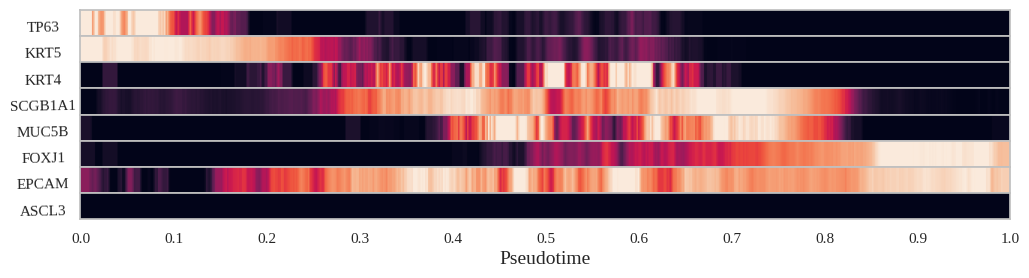

In [10]:
# Using script from my Github

gene_list = ["TP63", "KRT5", "KRT4", "SCGB1A1", "MUC5B", "FOXJ1", "EPCAM", "ASCL3"]
ax = pseudotime_gene_expression(subset, gene_list, smoothing = 10, zero_min = False)

## Calculate scores for TF programs

In [11]:
# Load the lists of TFs

tfs = pd.read_excel("drive/MyDrive/LU/Pavan_data/TF_programs.xlsx")
tfs[:3]

,Basal,Basal_Suprabasal,Suprabasal,Goblet,Secretory,Ciliated,Goblet_Secretory_Ciliated,Suprabasal_Goblet_Secretory_Ciliated,Suprabasal_Goblet_Secretory,Goblet_Secretory,Basal_Suprabasal_Goblet_Secretory,Secretory_Ciliated,General_all
0,TP63,HLF,ATF3,TET2,TARDBP,PHTF1,FUBP1,ELF3,HES4,ZNF593,UBTF,CENPS,RUNX1
1,ASCL2,IFI16,HES1,SOX4,ARID1A,ZC3H6,PBRM1,KDM5B,BHLHE40,ZNF326,CENPX,CASZ1,MBD2
2,ZFP36L2,ENO1,EGR1,AHR,PBX1,TMF1,PLSCR1,IRF1,KLF4,MIER1,ATF4,BOLA3,NCOR1


In [13]:
# Calculate number of TFs in each program and double-check that all are in the adata

cell_type_TF_dict = {}
for cell_type in tfs.columns:
  cell_type_TF_dict[cell_type] = tfs[cell_type].dropna().to_list()
for cell_type in cell_type_TF_dict.keys():
  print(cell_type, len(cell_type_TF_dict[cell_type]))
  for gene in cell_type_TF_dict[cell_type]:
    if gene not in adata.var_names:
      print(gene)

Basal 32
Basal_Suprabasal 10
Suprabasal 13
Goblet 14
Secretory 49
Ciliated 17
Goblet_Secretory_Ciliated 10
Suprabasal_Goblet_Secretory_Ciliated 4
Suprabasal_Goblet_Secretory 9
Goblet_Secretory 46
Basal_Suprabasal_Goblet_Secretory 6
Secretory_Ciliated 24
General_all 4


In [15]:
# Calculate scores
sc.pp.filter_genes(adata, min_cells = 30)
adata.X = adata.layers['lognorm'].copy()

for cell_type in cell_type_TF_dict.keys():
  print(cell_type)
  ls = cell_type_TF_dict[cell_type]
  sc.tl.score_genes(adata, ls, ctrl_size = 2000, score_name = cell_type + '_score')

Basal
Basal_Suprabasal
Suprabasal
Goblet
Secretory
Ciliated
Goblet_Secretory_Ciliated
Suprabasal_Goblet_Secretory_Ciliated
Suprabasal_Goblet_Secretory
Goblet_Secretory
Basal_Suprabasal_Goblet_Secretory
Secretory_Ciliated
General_all


In [18]:
# Prepare separated dataframes for the scores

subset = adata[adata.obs['anno_l2'].isin(['Basal cells', 'Suprabasal cells', 'Goblet cells', 'Secretory cells', 'Ciliated cells'])].copy()
df = pd.DataFrame()
for cell_type in cell_type_TF_dict.keys():
  df[cell_type + '_score'] = subset.obs[cell_type + '_score']
df_normalized = (df - df.min()) / (df.max() - df.min()) # min-max normalization
df_normalized['Pseudotime'] = subset.obs['dpt_pseudotime']
df_normalized = df_normalized.sort_values('Pseudotime')
del subset

df_normalized.columns = df_normalized.columns.str.replace('_', ' ')
df_normalized[:2]

,Basal score,Basal Suprabasal score,Suprabasal score,Goblet score,Secretory score,Ciliated score,Goblet Secretory Ciliated score,Suprabasal Goblet Secretory Ciliated score,Suprabasal Goblet Secretory score,Goblet Secretory score,Basal Suprabasal Goblet Secretory score,Secretory Ciliated score,General all score,Pseudotime
barcodes,,,,,,,,,,,,,,
GAGAGGTAGTCTAGAA-1,0.778963,0.588456,0.474531,0.465521,0.058820,0.207504,0.332247,0.192533,0.273660,0.401926,0.434412,0.299883,0.475180,0.000000
CAAGCTATCAGCGCAC-1-0,0.568893,0.573846,0.435994,0.246399,0.346005,0.308528,0.315253,0.354199,0.160995,0.480325,0.504824,0.344666,0.568784,0.003275


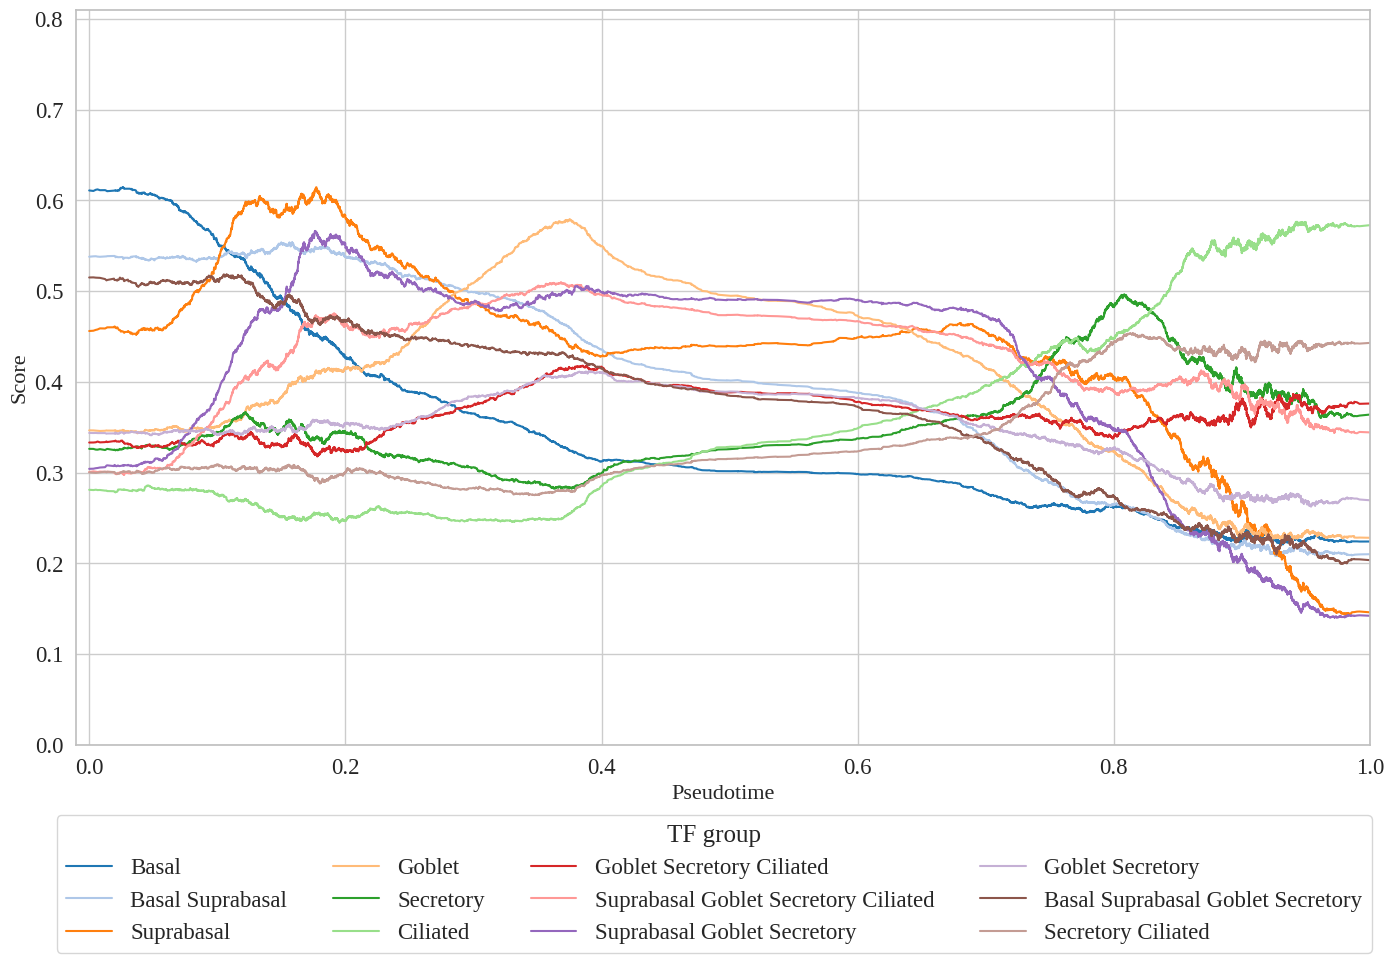

In [35]:
cell_types = list(cell_type_TF_dict.keys())
cell_types = [item.replace('_', ' ') for item in cell_types]
colors = sns.color_palette("tab20", len(cell_types))
color_map = dict(zip(cell_types, colors))

fig, ax = plt.subplots(figsize=(15, 10))
for cell_type in cell_types:
  if cell_type not in ['General all']:
    ax.plot(df_normalized['Pseudotime'],
        df_normalized[cell_type + ' score'].rolling(400, min_periods=1, center = True).mean(),
        label=cell_type, color=color_map[cell_type])

ax.set_ylabel("Score", fontsize=16)
ax.set_xlabel("Pseudotime", fontsize=16)
ax.legend(title="TF group", bbox_to_anchor = (1.01,-0.08), ncols = 4)
plt.tight_layout()
plt.ylim(0, 0.81); plt.xlim(-0.01, 1);

## Crucial genes on UMAP

TP63
HLF
MKI67
TOP2A


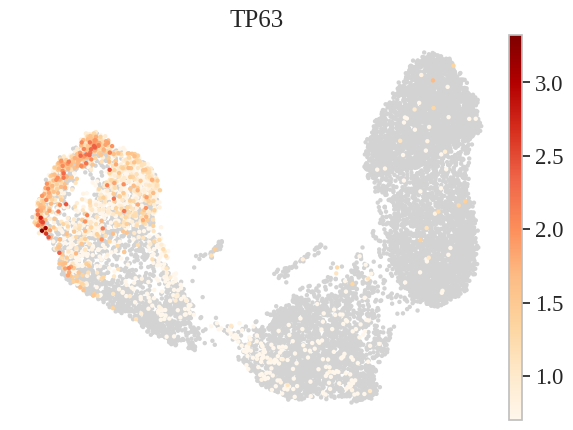

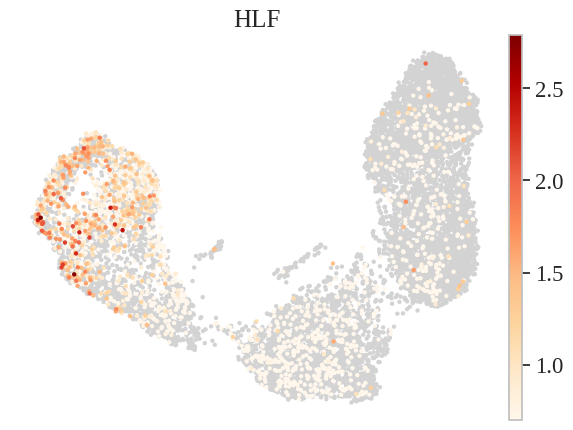

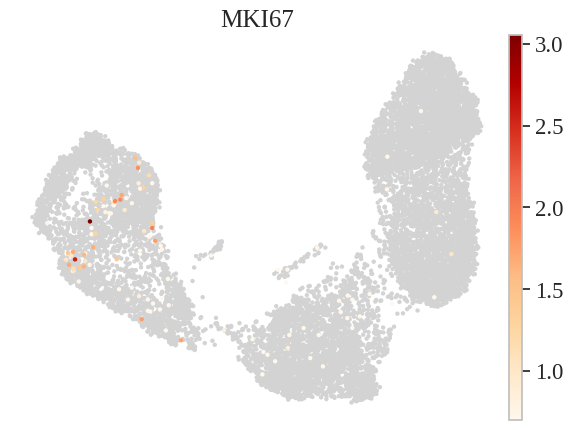

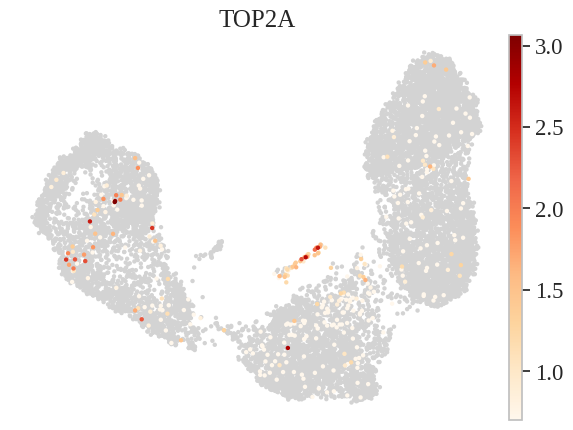

In [38]:
plt.rcParams['font.family'] = 'Liberation Serif'

genes_to_plot = ["TP63", "HLF", "MKI67", "TOP2A"]

for gene in genes_to_plot:
  print(gene)
  adata.obs[gene +"_zero"] = adata[:, gene].X.A == 0

for gene in genes_to_plot:
  sub1 = adata[adata.obs[gene+'_zero'] == True]
  sub2 = adata[adata.obs[gene+'_zero'] == False]
  fig, ax = plt.subplots(1,1, figsize = (7,5))
  sc.pl.umap(sub1, show = False, ax = ax, frameon = False, title = "", s = 40)
  sc.pl.umap(sub2, show = False, ax = ax, color = gene, cmap = "OrRd", layer = 'lognorm', vmin = 0.7, frameon = False, title = gene, s = 40)
  del sub1
  del sub2